[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part5-commercial-analytics/sec5.3_sales_forecasting.ipynb)

# Sales Forecasting and Scenario Planning

Companion notebook for **Chapter 5.3**. It is late September of the
planning year, and "will we hit the target?" needs three answers:

1. Where will sales land if the current plan continues?
2. How likely are we to reach the target?
3. Which measured actions could change those odds, and by how much?

The workflow: build a baseline for the current plan → validate it on the
13-week decision horizon with rolling origins → simulate complete
year-end paths → add separately measured marketing increments → read the
result as a probability of hitting the target, not a single number.

**Data**: an author-generated synthetic weekly e-commerce revenue series
(six 52-week fiscal years on a real calendar, with holiday peaks whose
strength varies by year). Synthetic because no public retail dataset
combines several years of real-calendar history, a repeatable holiday
peak, AND a known causal campaign effect under a redistributable license.
The generator, its seed, and the ground truth ship with the repo
(`sales_forecast_data_generation.py`); the closing section checks our
workflow against the truth the analyst never sees in real life.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [2]:
# Colab bootstrap: make the `msbook` helper package importable and, on a
# fresh runtime, install this chapter's dependencies from the Part 5
# requirements file. Local / conda users already have both via the repo's
# environment.yml + `pip install -e .`, so nothing is reinstalled there.
import importlib.util
import os
import sys

try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO_DIR = "marketing-science-in-python"
    _REPO = f"https://github.com/takechanman1228/{_REPO_DIR}.git"
    if not os.path.isdir(_REPO_DIR):
        subprocess.run(["git", "clone", "-q", _REPO, _REPO_DIR], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", _REPO_DIR,
         "-r", f"{_REPO_DIR}/notebooks/part5-commercial-analytics/requirements.txt"],
        check=True,
    )
    import msbook  # noqa: F401

_missing = [name for name in ("statsmodels", "lightgbm", "mlforecast", "prophet")
            if importlib.util.find_spec(name) is None]
if _missing:
    raise RuntimeError(
        "Missing Chapter 5.3 dependencies: " + ", ".join(_missing)
        + ". Install notebooks/part5-commercial-analytics/requirements.txt."
    )

# TimesFM has its own message because it has its own remedy: it is measured in
# the backtest but deliberately kept out of the default install, so a missing
# TimesFM must stop the run rather than quietly publish a table one row short.
if importlib.util.find_spec("timesfm") is None:
    raise RuntimeError(
        "Chapter 5.3 measures Google TimesFM in the rolling-origin backtest. It "
        "needs PyTorch and a foundation-model checkpoint, so it is an opt-in "
        "install:\n"
        "  pip install -r notebooks/part5-commercial-analytics/requirements-timesfm.txt\n"
        "Only reading? The committed .ipynb already carries every TimesFM output."
    )
from msbook.paths import chapter_images, chapter_generated
from msbook.forecasting_utils import (
    interval_coverage,
    make_forecast_origins,
    normalized_bias,
    quantile_crossing_rate,
    total_window_error,
    wape,
)

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

IMG_DIR = chapter_images(part="5", chapter="sec5.3")
DATA_DIR = chapter_generated(part="5", chapter="sec5.3-sales-forecast")


def save_fig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(IMG_DIR / name, **kw)

## 1. The series and the situation at the origin

The company plans in fixed 52-week fiscal years that close in late
December, so every year-end horizon contains the holiday peak (Christmas
falls in fiscal week 51 in the earlier years and week 52 in the later
ones, because a real year is slightly longer than 52 weeks). It is now the
end of fiscal week 39 (late September of FY2019): 39 weeks are behind
us, 13 remain.

One discipline runs through this notebook: until the closing section,
every number and chart uses only `history`, the data available at the
forecast origin. The realized final 13 weeks stay unseen until then.

In [3]:
weekly = pd.read_csv(DATA_DIR / "weekly_sales.csv", parse_dates=["week"])
assert len(weekly) == 312 and weekly["fiscal_week"].max() == 52

HORIZON = 13

# Train lengths ending at fiscal week 39 (late September) of each year.
# FY2015's origin has less than two full seasonal cycles of history, so the
# seasonal models cannot be fit there; the comparable replicas start FY2016.
_sept = weekly.index[weekly["fiscal_week"] == 39] + 1
SEPT_ORIGINS = [int(o) for o in _sept if o >= 104 and o != _sept[-1]]
LIVE_ORIGIN = int(_sept[-1])
assert SEPT_ORIGINS == [143, 195, 247] and LIVE_ORIGIN == 299

# Everything the analyst can see at the origin. `weekly`'s `sales` column is
# read again only in the closing section. The future rows of the calendar
# columns (`fiscal_week`, `holiday_week`, `bau_promotion`) are read earlier, by
# LightGBM and Prophet, because a promotion calendar is known in advance; no
# model ever sees a future `sales` value.
history = weekly.iloc[:LIVE_ORIGIN]
y = history["sales"].to_numpy(dtype=float)

completed = history.groupby("fiscal_year")["sales"].sum().loc[:2018]
sales_so_far = y[260:LIVE_ORIGIN].sum()
prior_same = y[260 - 52:LIVE_ORIGIN - 52].sum()
print("completed fiscal-year totals ($M):")
print((completed / 1e6).round(2).to_string())
print(f"\nsales so far, FY2019 wk1-39: ${sales_so_far/1e6:.2f}M "
      f"({sales_so_far / prior_same - 1:+.1%} vs the same weeks last year)")

completed fiscal-year totals ($M):
fiscal_year
2014    8.27
2015    8.73
2016    9.37
2017    9.90
2018   10.30

sales so far, FY2019 wk1-39: $8.02M (+7.3% vs the same weeks last year)


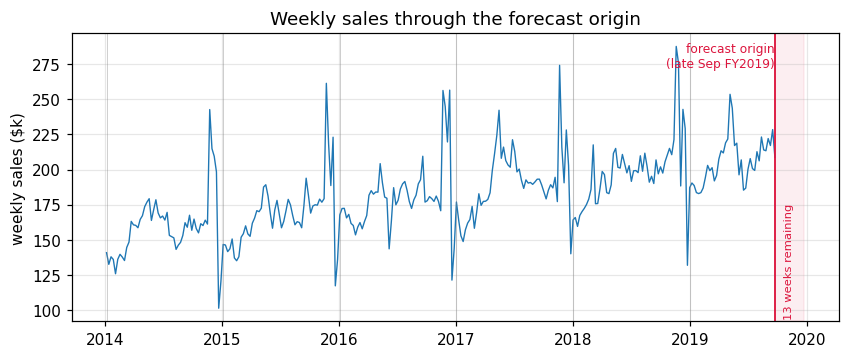

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(history["week"], history["sales"] / 1e3, lw=0.9, color="#1f77b4")
for fy_start in history.loc[history["fiscal_week"] == 1, "week"]:
    ax.axvline(fy_start, color="gray", lw=0.6, alpha=0.4)
ax.axvline(history["week"].iloc[-1], color="crimson", lw=1.2)
ax.annotate("forecast origin\n(late Sep FY2019)",
            xy=(history["week"].iloc[-1], ax.get_ylim()[1] * 0.92),
            fontsize=8, color="crimson", ha="right")
# The 13 weeks still to come: shaded from the origin date and HORIZON alone,
# so the chart shows the decision window without touching the holdout.
_origin_wk = history["week"].iloc[-1]
_end_wk = _origin_wk + pd.Timedelta(weeks=HORIZON)
ax.axvspan(_origin_wk, _end_wk, color="crimson", alpha=0.07)
ax.text(_origin_wk + pd.Timedelta(weeks=HORIZON / 2), ax.get_ylim()[0] * 1.02,
        f"{HORIZON} weeks remaining", rotation=90, ha="center", va="bottom",
        fontsize=7.5, color="crimson")
ax.set_ylabel("weekly sales ($k)")
ax.set_title("Weekly sales through the forecast origin")
save_fig(fig, "where_we_stand.png")
plt.show()

## 2. Baseline models for business as usual

Before any model, something to beat:

- **Naive** repeats the last observed week. Into a holiday quarter it is
  structurally blind, which is exactly why it is the floor to beat.
- **Seasonal naive** repeats the same fiscal week last year: the honest
  version of "apply last year's pattern".
- **ETS** (exponential smoothing) represents level, trend, and seasonality
  as explicit components. We fit it on log sales because the seasonal swing
  scales with the level, and keep two candidates: with and without the
  seasonal term. The backtest decides whether the seasonal term earns its
  52 extra parameters.
- **LightGBM** on lag features (1, 4, 13, 52 plus a 4-week rolling mean)
  with the fiscal week and the holiday/promotion calendar as features. It
  enters as a fixed, lightly regularized comparator, not a tuned production
  model.
- **Prophet** decomposes a changing trend, a yearly season, and calendar
  effects. The tool many analysts open first, so it competes on the same
  terms as the rest, with the same future-known calendar columns LightGBM
  gets.
- **TimesFM 2.5** is a pretrained foundation model used zero-shot: no
  fitting, and nothing but the sales history. Checkpoint 2.5 rather than
  3.0, whose weights are restricted to non-commercial use.

In [5]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


def fit_ets(train, seasonal=None):
    """Damped-trend ETS on log sales; seasonal='add' adds a 52-week term."""
    model = ETSModel(
        pd.Series(np.log(np.asarray(train, dtype=float))),
        error="add", trend="add", damped_trend=True,
        seasonal=seasonal, seasonal_periods=52 if seasonal else None,
    )
    return model.fit(disp=False)


def ets_point(result, origin, h=HORIZON):
    """Median point forecast in dollars."""
    pred = result.get_prediction(start=origin, end=origin + h - 1)
    return np.exp(pred.predicted_mean.to_numpy())


def simulate_paths(result, h=HORIZON, repetitions=5000, seed=SEED):
    """Complete h-week forecast paths in dollars, shape (h, repetitions).

    Bootstrap: resample the model's own one-step residuals instead of
    assuming they are normal, so fat weeks stay fat in the simulation. The
    residuals are re-centered first: their in-sample mean is a property of
    the fit, and leaving it in would shift every simulated path by that
    bias instead of representing uncertainty (any bias correction should
    be explicit, not smuggled in through the error draws). The error array
    is drawn with our own seeded generator (statsmodels' built-in
    bootstrap ignores `random_state`, which would make every run of this
    notebook report slightly different numbers). `anchor="end"` continues
    the path from the end of the training sample; without it, statsmodels
    simulates from the START of the sample. One approximation to know
    about: draws are independent across weeks, so any dependence left in
    the residuals is not reproduced (a block bootstrap is the next step
    if that matters).
    """
    rng = np.random.default_rng(seed)
    residuals = np.asarray(result.resid, dtype=float)
    residuals = residuals[np.isfinite(residuals)]
    residuals = residuals - residuals.mean()
    errors = rng.choice(residuals, size=(h, repetitions), replace=True)
    sim = result.simulate(
        nsimulations=h, repetitions=repetitions,
        random_errors=errors, anchor="end",
    )
    return np.exp(np.asarray(sim))


def naive_forecast(train, h=HORIZON):
    return np.repeat(np.asarray(train, dtype=float)[-1], h)


def seasonal_naive_forecast(series, origin, h=HORIZON):
    return np.asarray(series, dtype=float)[origin - 52:origin - 52 + h]

In [6]:
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

LGBM_FEATURES = ["fiscal_week", "holiday_week", "bau_promotion"]


def make_quantile_forecaster():
    """Three quantile LightGBMs sharing one feature pipeline."""
    def lgbm(alpha):
        return LGBMRegressor(
            objective="quantile", alpha=alpha,
            n_estimators=400, learning_rate=0.03, num_leaves=31,
            random_state=SEED, n_jobs=1, verbosity=-1,
        )

    return MLForecast(
        models={"p10": lgbm(0.10), "p50": lgbm(0.50), "p90": lgbm(0.90)},
        freq="W-MON",
        lags=[1, 4, 13, 52],
        lag_transforms={1: [RollingMean(window_size=4)]},
        num_threads=1,
    )


mlf_frame = (
    weekly.rename(columns={"week": "ds", "sales": "y"})
    .assign(unique_id="total")[["unique_id", "ds", "y", *LGBM_FEATURES]]
)


def lgbm_forecast(origin, h=HORIZON):
    forecaster = make_quantile_forecaster()
    forecaster.fit(mlf_frame.iloc[:origin], static_features=[])
    future_x = mlf_frame.iloc[origin:origin + h][["unique_id", "ds", *LGBM_FEATURES]]
    return forecaster.predict(h=h, X_df=future_x)

In [7]:
# Prophet: the model many teams reach for first. Fitted on log sales so its
# additive components act on a multiplicative revenue scale, matching `fit_ets`.
# It gets the same future-known calendar columns LightGBM gets; those describe
# the plan already on the books, not a causal lever.
from prophet import Prophet

PROPHET_REGRESSORS = ["holiday_week", "bau_promotion"]


def prophet_forecast(origin, h=HORIZON):
    """Median forecast in dollars, trained only on weeks before `origin`."""
    train_df = (
        weekly.iloc[:origin]
        .rename(columns={"week": "ds", "sales": "y"})[["ds", "y", *PROPHET_REGRESSORS]]
        .copy()
    )
    train_df["y"] = np.log(train_df["y"].to_numpy(dtype=float))
    model = Prophet(
        growth="linear", yearly_seasonality=True, weekly_seasonality=False,
        daily_seasonality=False, seasonality_mode="additive",
        uncertainty_samples=0,          # point forecast only: deterministic MAP fit
    )
    for name in PROPHET_REGRESSORS:
        model.add_regressor(name, standardize=False)
    model.fit(train_df)
    future = (
        weekly.iloc[origin:origin + h]
        .rename(columns={"week": "ds"})[["ds", *PROPHET_REGRESSORS]]
        .copy()
    )
    return np.exp(model.predict(future)["yhat"].to_numpy(dtype=float))

In [8]:
# TimesFM: a pretrained time-series foundation model, used zero-shot. It sees
# only the sales history, no calendar columns, which is the claim being tested.
# Checkpoint 2.5, not 3.0: the 3.0 weights are restricted to non-commercial,
# non-production use, while 2.5 is Apache-2.0.
#
# Every setting below exists to keep these numbers reproducible, since the
# chapter quotes them to one decimal of a percent: a pinned checkpoint
# revision, no TF32 (that is what "high" would enable), no compiled kernels,
# one thread, and an explicit CPU device.
import torch
import timesfm

TIMESFM_CHECKPOINT = "google/timesfm-2.5-200m-pytorch"
TIMESFM_REVISION = "1d952420fba87f3c6dee4f240de0f1a0fbc790e3"

torch.set_grad_enabled(False)
torch.set_num_threads(1)
torch.set_float32_matmul_precision("highest")
torch.manual_seed(SEED)


def load_timesfm():
    """Load and compile once: re-loading per origin would re-read the weights."""
    model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        TIMESFM_CHECKPOINT, revision=TIMESFM_REVISION, torch_compile=False,
    )
    model.compile(
        timesfm.ForecastConfig(
            max_context=1024, max_horizon=HORIZON, normalize_inputs=True,
            use_continuous_quantile_head=True, force_flip_invariance=True,
            infer_is_positive=True, fix_quantile_crossing=True,
        )
    )
    return model


TIMESFM = load_timesfm()


def timesfm_forecast(train, h=HORIZON):
    """Median forecast in dollars from the raw history alone."""
    point, _ = TIMESFM.forecast(horizon=h, inputs=[np.asarray(train, dtype=np.float32)])
    return np.asarray(point[0], dtype=float)

What do the seven models actually predict for the 13 weeks that decide
the year? Each is fitted on the same history, up to the live late-September
origin, and the realized weeks stay unseen. They disagree by a wide margin
over the holiday peak, and nothing in this chart says which one to believe.
That is what the rolling-origin backtest below is for.

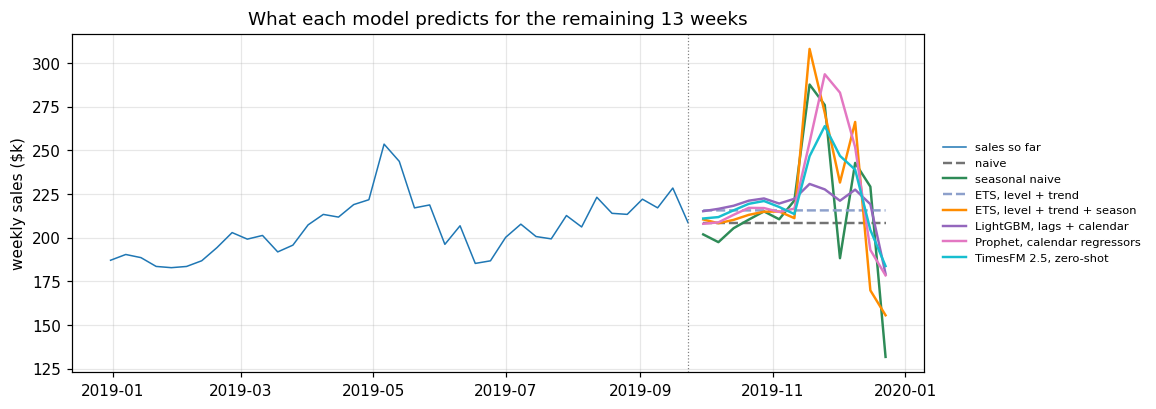

In [9]:
# `live_ets` is fitted once, here, and reused by the simulation in section 5:
# two fits of the same spec would let the chart and the published numbers
# describe different models if either is ever tuned.
_ets_none_live = fit_ets(y[:LIVE_ORIGIN], seasonal=None)
live_ets = fit_ets(y[:LIVE_ORIGIN], seasonal="add")
_benchmarks = {
    "naive": (naive_forecast(y[:LIVE_ORIGIN]), "0.45", "--"),
    "seasonal naive": (seasonal_naive_forecast(y, LIVE_ORIGIN), "seagreen", "-"),
    "ETS, level + trend": (ets_point(_ets_none_live, LIVE_ORIGIN), "#8da0cb", "--"),
    "ETS, level + trend + season": (ets_point(live_ets, LIVE_ORIGIN),
                                    "darkorange", "-"),
    "LightGBM, lags + calendar": (lgbm_forecast(LIVE_ORIGIN)["p50"].to_numpy(),
                                  "#9467bd", "-"),
    "Prophet, calendar regressors": (prophet_forecast(LIVE_ORIGIN), "#e377c2", "-"),
    "TimesFM 2.5, zero-shot": (timesfm_forecast(y[:LIVE_ORIGIN]), "#17becf", "-"),
}

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(history["week"].iloc[260:], y[260:] / 1e3, lw=1.0, color="#1f77b4",
        label="sales so far")
_fc_wk = weekly["week"].iloc[LIVE_ORIGIN:LIVE_ORIGIN + HORIZON]
for _name, (_fc, _color, _style) in _benchmarks.items():
    ax.plot(_fc_wk, np.asarray(_fc) / 1e3, lw=1.6, ls=_style, color=_color, label=_name)
ax.axvline(history["week"].iloc[-1], color="gray", lw=0.8, ls=":")
ax.set_ylabel("weekly sales ($k)")
ax.set_title("What each model predicts for the remaining 13 weeks")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7.5,
          frameon=False)                      # outside: seven paths crowd the axes
save_fig(fig, "naive_vs_seasonal.png")
plt.show()

## 3. A random split answers a different question

The habitual evaluation is a random train/test split over the rows. Two
things are wrong with it here. First, shuffled rows let the model train on
weeks that come *after* the ones it predicts, and with lag-1 features the
test rows sit between known neighbors, so the score is flattering. Second,
and more fundamental: a random split scores one-row-at-a-time
interpolation. It cannot even produce the object the decision needs, a
13-week-ahead path from a fixed origin. Whatever number it reports answers
a different question.

In [10]:
_prep = (
    make_quantile_forecaster()
    .preprocess(mlf_frame.iloc[:LIVE_ORIGIN], static_features=[])
    .dropna()
)
_X_cols = [c for c in _prep.columns if c not in ("unique_id", "ds", "y")]
_shuffle = np.random.default_rng(SEED).permutation(len(_prep))
_cut = int(len(_prep) * 0.8)
_tr, _te = _prep.iloc[_shuffle[:_cut]], _prep.iloc[_shuffle[_cut:]]
_m = LGBMRegressor(objective="quantile", alpha=0.5, n_estimators=400,
                   learning_rate=0.03, num_leaves=31, random_state=SEED,
                   n_jobs=1, verbosity=-1)
_m.fit(_tr[_X_cols], _tr["y"])
random_split_wape = wape(_te["y"], _m.predict(_te[_X_cols]))
print(f"LightGBM, random 80/20 split: WAPE {random_split_wape:.1%} "
      "(compare with the rolling-origin column below)")

LightGBM, random 80/20 split: WAPE 4.5% (compare with the rolling-origin column below)


## 4. Rolling-origin backtest on the decision horizon

The rule: every model sees only data up to the forecast origin, and is
scored on the next 13 weeks. Because every fiscal year has the same
52-week shape, the question "forecast year-end from late September" can be
replayed at the *same calendar point* of FY2016, FY2017, and FY2018: three
honest replicas of the exact decision (FY2015's September origin has less
than two seasonal cycles of history, so the seasonal models cannot be
estimated there).

Two point metrics per model: weekly WAPE (the error a planner recognizes)
and the signed error of the 13-week TOTAL (the one the year-end question
depends on, because weekly misses partly cancel inside a sum).

In [11]:
rows = []
sept_ets_results = {}
for origin in SEPT_ORIGINS:
    train, actual = y[:origin], y[origin:origin + HORIZON]
    ets_none = fit_ets(train, seasonal=None)
    ets_add = fit_ets(train, seasonal="add")
    sept_ets_results[origin] = ets_add
    lgbm_pred = lgbm_forecast(origin)
    forecasts = {
        "Naive": naive_forecast(train),
        "Seasonal naive": seasonal_naive_forecast(y, origin),
        "ETS (level + trend)": ets_point(ets_none, origin),
        "ETS (level + trend + season)": ets_point(ets_add, origin),
        "LightGBM (lags + calendar)": lgbm_pred["p50"].to_numpy(),
        "Prophet (calendar regressors)": prophet_forecast(origin),
        "TimesFM 2.5 (zero-shot)": timesfm_forecast(train),
    }
    for name, fc in forecasts.items():
        rows.append({
            "model": name, "origin": origin,
            "weekly_wape": wape(actual, fc),
            "total_error": total_window_error(actual, fc),
        })

backtest = (
    pd.DataFrame(rows)
    .groupby("model", sort=False)
    .agg(weekly_wape=("weekly_wape", "mean"),
         mean_abs_total_error=("total_error", lambda s: s.abs().mean()),
         total_bias=("total_error", "mean"))
)
# A formatted frame, not `.style`: a Styler's text/plain fallback is its
# memory address, so the printed output would change on every run whether or
# not a result moved.
backtest.map(lambda v: f"{v:.1%}")

,weekly_wape,mean_abs_total_error,total_bias
model,,,
Naive,13.2%,6.8%,-6.8%
Seasonal naive,8.6%,5.5%,-5.5%
ETS (level + trend),13.3%,4.7%,-4.7%
ETS (level + trend + season),7.4%,2.6%,-1.3%
LightGBM (lags + calendar),12.3%,5.7%,-5.7%
Prophet (calendar regressors),10.5%,5.3%,1.8%
TimesFM 2.5 (zero-shot),10.8%,2.6%,-1.5%


In [12]:
print(backtest.map(lambda v: f"{v:+.1%}").to_string())
print(f"\nLightGBM random-split WAPE was {random_split_wape:.1%}; "
      "rolling-origin evaluation is the honest one.")
# The chapter's whole second half is built on `fit_ets` + `simulate_paths`, so
# which model wins here decides what the rest of the chapter can use. Prophet
# and TimesFM enter the backtest table and the live-origin chart only; they
# never reach the scenario work. Marginal weekly quantiles cannot be summed
# into a distribution for the quarter total, which is what the decision needs.
print(f"lowest 13-week total error: {backtest['mean_abs_total_error'].idxmin()}")
print(f"lowest weekly WAPE: {backtest['weekly_wape'].idxmin()}")

                              weekly_wape mean_abs_total_error total_bias
model                                                                    
Naive                              +13.2%                +6.8%      -6.8%
Seasonal naive                      +8.6%                +5.5%      -5.5%
ETS (level + trend)                +13.3%                +4.7%      -4.7%
ETS (level + trend + season)        +7.4%                +2.6%      -1.3%
LightGBM (lags + calendar)         +12.3%                +5.7%      -5.7%
Prophet (calendar regressors)      +10.5%                +5.3%      +1.8%
TimesFM 2.5 (zero-shot)            +10.8%                +2.6%      -1.5%

LightGBM random-split WAPE was 4.5%; rolling-origin evaluation is the honest one.
lowest 13-week total error: ETS (level + trend + season)
lowest weekly WAPE: ETS (level + trend + season)


The seasonal ETS wins on both metrics, but the interesting row is TimesFM:
given nothing but the raw series, a pretrained model lands within a tenth of a
point of it on the 13-week total while being clearly worse week by week.
Prophet, the tool most teams reach for first, barely clears seasonal naive on
the total. LightGBM, with 3-4 years of weekly rows, cannot compete on a single
series. The seasonal ETS is the baseline from here on: it wins the comparison
AND it produces the complete forecast distribution the next section needs,
which a per-week quantile from any of the others cannot supply.

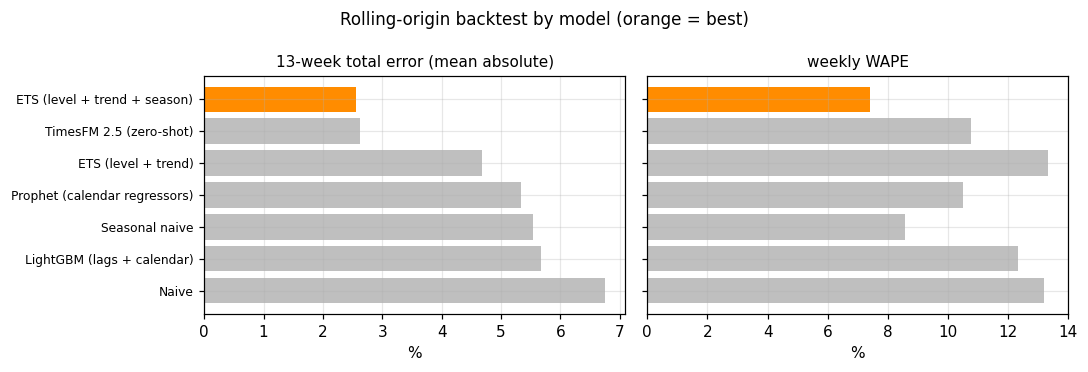

In [13]:
# Notebook-only diagnostic: the same two metrics side by side, because with
# seven models the overlay chart above stops working as a comparison.
_bt = backtest.sort_values("mean_abs_total_error")
_pos = np.arange(len(_bt))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for _ax, _col, _title in (
    (axes[0], "mean_abs_total_error", "13-week total error (mean absolute)"),
    (axes[1], "weekly WAPE", "weekly WAPE"),
):
    _key = "weekly_wape" if _col == "weekly WAPE" else _col
    _vals = _bt[_key].to_numpy()
    _best = int(_vals.argmin())
    _ax.barh(_pos, _vals * 100,
             color=["darkorange" if i == _best else "0.75" for i in range(len(_bt))])
    _ax.set_xlabel("%")
    _ax.set_title(_title, fontsize=10)
    _ax.grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()          # once: sharey propagates it to both panels
axes[0].set_yticks(_pos)
axes[0].set_yticklabels(_bt.index, fontsize=8)
fig.suptitle("Rolling-origin backtest by model (orange = best)", fontsize=11)
fig.tight_layout()
save_fig(fig, "backtest_by_model.png")
plt.show()

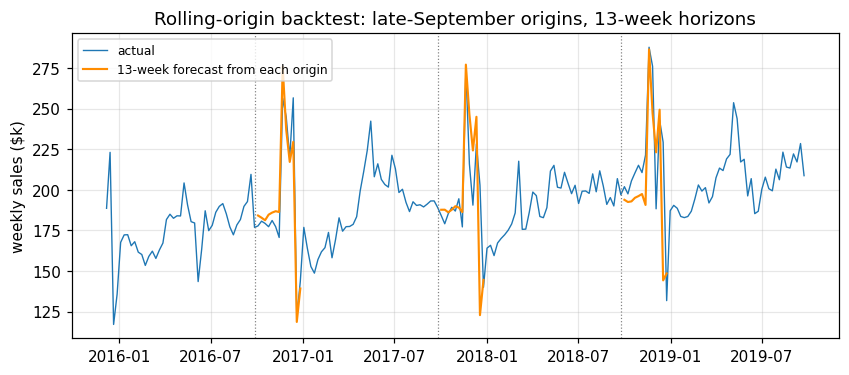

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.6))
show_from = 100
ax.plot(history["week"].iloc[show_from:], y[show_from:] / 1e3,
        lw=0.9, color="#1f77b4", label="actual")
for origin in SEPT_ORIGINS:
    fc = ets_point(sept_ets_results[origin], origin)
    wk = history["week"].iloc[origin:origin + HORIZON]
    ax.plot(wk, fc / 1e3, lw=1.4, color="darkorange")
    ax.axvline(history["week"].iloc[origin - 1], color="gray", lw=0.8, ls=":")
ax.plot([], [], lw=1.4, color="darkorange", label="13-week forecast from each origin")
ax.set_ylabel("weekly sales ($k)")
ax.set_title("Rolling-origin backtest: late-September origins, 13-week horizons")
ax.legend(loc="upper left", fontsize=8)
save_fig(fig, "rolling_origin_backtest.png")
plt.show()

### Does the interval behave like an interval?

The decision object is the 13-week total, so the interval to validate is
the interval on the TOTAL: simulate complete 13-week paths at each
historical origin, sum each path, and check whether the realized total
fell inside the 80% band. Weekly coverage would not answer this; weekly
errors are correlated over the horizon, and a sum inherits that
correlation. Non-overlapping windows every 13 weeks give the cleanest
count; the three September replicas answer the year-end question
specifically.

In [15]:
# Origins stop before the live one: at the end of September you can only
# validate on windows whose outcomes are already history.
origin_dates = make_forecast_origins(
    weekly["week"].iloc[:LIVE_ORIGIN],
    min_train_weeks=104, horizon=HORIZON, step=HORIZON,
)
coverage_origins = [
    int(weekly.index[weekly["week"] == d][0]) + 1 for d in origin_dates
]

# The chart below plots every origin in this union but titles itself with the
# coverage-window count, so the September replicas must be part of that grid.
assert set(SEPT_ORIGINS) <= set(coverage_origins)

coverage_hits, sept_hits = [], []
evaluated_upside_misses = {}
interval_records = {}            # origin -> (P10, P90, realized total, inside?)
for origin in sorted(set(coverage_origins) | set(SEPT_ORIGINS)):
    train, actual = y[:origin], y[origin:origin + HORIZON]
    result = sept_ets_results.get(origin) or fit_ets(train, seasonal="add")
    totals = simulate_paths(result, repetitions=2000, seed=origin).sum(axis=0)
    lo, hi = np.percentile(totals, [10, 90])
    hit = bool(lo <= actual.sum() <= hi)
    interval_records[origin] = (lo, hi, actual.sum(), hit)
    if origin in coverage_origins:
        coverage_hits.append(hit)
    if origin in SEPT_ORIGINS:
        sept_hits.append(hit)
    evaluated_upside_misses[origin] = actual.sum() / np.median(totals) - 1

largest_evaluated_upside_miss = max(evaluated_upside_misses.values())
largest_miss_origin = max(evaluated_upside_misses, key=evaluated_upside_misses.get)
largest_sept_upside_miss = max(evaluated_upside_misses[o] for o in SEPT_ORIGINS)
n_windows = len(coverage_hits)
print(f"13-week-total 80% interval, non-overlapping validation windows: "
      f"{sum(coverage_hits)} of {n_windows} inside")
print(f"September replicas: {sum(sept_hits)} of {len(sept_hits)} inside")
print(f"largest upside miss among the {n_windows} non-overlapping validation "
      f"windows: {largest_evaluated_upside_miss:+.1%} "
      f"(window starting {weekly['week'].iloc[largest_miss_origin].date()})")
print(f"largest upside miss of a September window: {largest_sept_upside_miss:+.1%}")

13-week-total 80% interval, non-overlapping validation windows: 12 of 15 inside
September replicas: 2 of 3 inside
largest upside miss among the 15 non-overlapping validation windows: +11.9% (window starting 2016-07-04)
largest upside miss of a September window: +6.0%


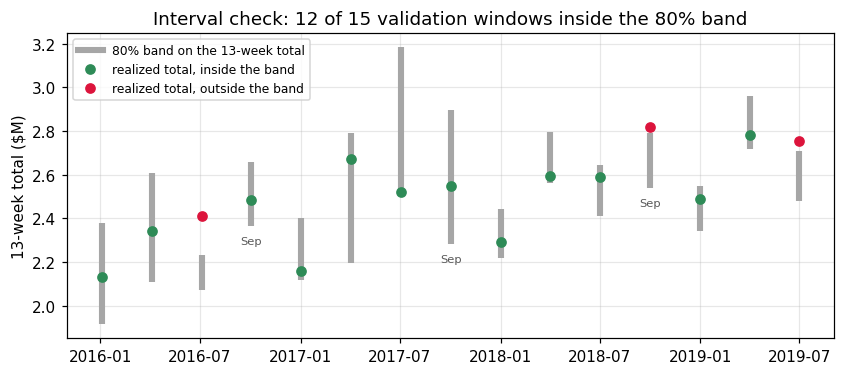

In [16]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for origin, (lo, hi, realized, hit) in sorted(interval_records.items()):
    start = weekly["week"].iloc[origin]
    ax.plot([start, start], [lo / 1e6, hi / 1e6], color="0.65", lw=4,
            solid_capstyle="butt")
    ax.plot(start, realized / 1e6, "o", color="seagreen" if hit else "crimson",
            ms=6, zorder=3)
    if origin in SEPT_ORIGINS:
        ax.annotate("Sep", (start, lo / 1e6), textcoords="offset points",
                    xytext=(0, -12), ha="center", fontsize=7.5, color="0.35")
ax.plot([], [], color="0.65", lw=4, label="80% band on the 13-week total")
ax.plot([], [], "o", color="seagreen", label="realized total, inside the band")
ax.plot([], [], "o", color="crimson", label="realized total, outside the band")
ax.set_ylabel("13-week total ($M)")
ax.set_title(f"Interval check: {sum(coverage_hits)} of {n_windows} "
             "validation windows inside the 80% band")
ax.legend(loc="upper left", fontsize=8)
save_fig(fig, "interval_coverage.png")
plt.show()

## 5. Simulating the year-end outcome

The year-end total is 39 completed weeks plus 13 uncertain ones. Its P10 is
NOT the sum of thirteen weekly P10s: weekly quantiles ignore the
correlation between weeks, and quantiles do not add. So we simulate
complete 13-week paths from the fitted model, sum each path, and read the
distribution of year-end totals.

In [17]:
# The annual target, fixed BEFORE the simulation below was first run and not
# adjusted afterwards: last fiscal year's sales plus 8%. It is an
# illustrative planning threshold for this worked example; in practice the
# number comes from the business, not from the data.
TARGET_MULTIPLIER = 1.08
target = completed.loc[2018] * TARGET_MULTIPLIER
print(f"annual target: FY2018 total ${completed.loc[2018]/1e6:.2f}M x "
      f"{TARGET_MULTIPLIER} = ${target/1e6:.2f}M")

annual target: FY2018 total $10.30M x 1.08 = $11.12M


In [18]:
# `live_ets` is the seasonal ETS fitted in section 2 for the benchmark chart.
paths = simulate_paths(live_ets, repetitions=5000, seed=SEED)  # (13, 5000)
remaining = paths.sum(axis=0)
year_end_bau = sales_so_far + remaining

p10, p50, p90 = np.percentile(year_end_bau, [10, 50, 90])
p_hit_bau = (year_end_bau >= target).mean()
print(f"BAU year-end: P10 ${p10/1e6:.2f}M / P50 ${p50/1e6:.2f}M / "
      f"P90 ${p90/1e6:.2f}M")
print(f"P(hit target | business as usual) = {p_hit_bau:.0%}")

BAU year-end: P10 $10.79M / P50 $10.91M / P90 $11.05M
P(hit target | business as usual) = 4%


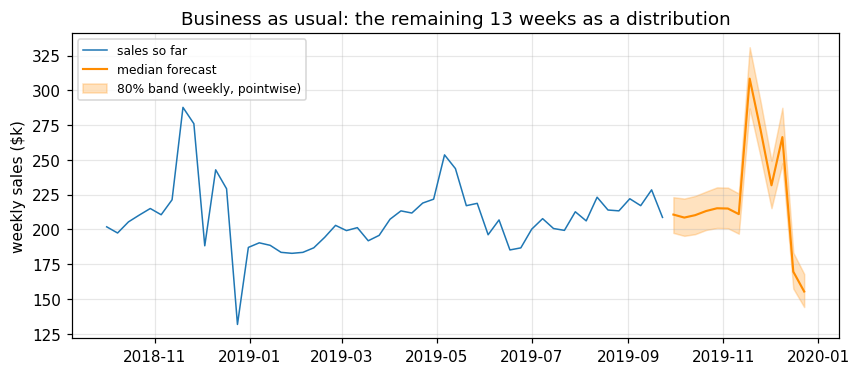

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.6))
hist_from = 247
wk_hist = weekly["week"].iloc[hist_from:LIVE_ORIGIN]
ax.plot(wk_hist, y[hist_from:LIVE_ORIGIN] / 1e3, lw=1.0, color="#1f77b4",
        label="sales so far")
wk_fc = weekly["week"].iloc[LIVE_ORIGIN:LIVE_ORIGIN + HORIZON]
path_p10, path_p50, path_p90 = np.percentile(paths, [10, 50, 90], axis=1)
ax.plot(wk_fc, path_p50 / 1e3, lw=1.4, color="darkorange", label="median forecast")
ax.fill_between(wk_fc, path_p10 / 1e3, path_p90 / 1e3, color="darkorange",
                alpha=0.25, label="80% band (weekly, pointwise)")
ax.set_ylabel("weekly sales ($k)")
ax.set_title("Business as usual: the remaining 13 weeks as a distribution")
ax.legend(loc="upper left", fontsize=8)
# Notebook-only since the chapter moved to the cumulative pacing chart:
# kept because it is where the weekly shape of the uncertainty is visible.
save_fig(fig, "fan_chart_total.png")
plt.show()

The same distribution as a pacing chart: cumulative sales through the year,
the remaining weeks as a band on the cumulative total, and the target as a
line. One picture answers the first two questions, where the year lands if
the current plan continues and how far that is from the target. The band is
on the cumulative total (each path summed), not the weekly band of the fan
chart above.

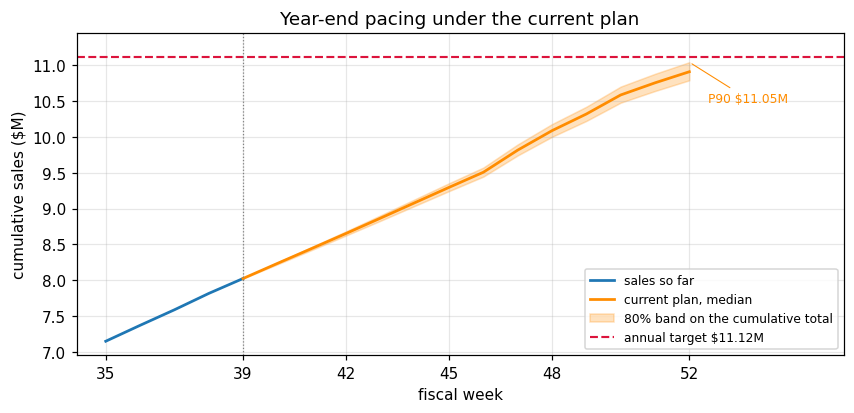

In [20]:
SHOW_FROM_WEEK = 35
_fy = history[history["fiscal_year"] == 2019]
_cum_so_far = _fy["sales"].cumsum().to_numpy() / 1e6
_fw = _fy["fiscal_week"].to_numpy()
_fw_future = np.arange(_fw[-1], _fw[-1] + HORIZON + 1)   # 39..52, joined at the origin
_cum_bau = np.vstack(
    [np.full(paths.shape[1], sales_so_far), sales_so_far + np.cumsum(paths, axis=0)]
) / 1e6
_b10, _b50, _b90 = np.percentile(_cum_bau, [10, 50, 90], axis=1)

fig, ax = plt.subplots(figsize=(9, 3.8))
_m = _fw >= SHOW_FROM_WEEK
ax.plot(_fw[_m], _cum_so_far[_m], lw=1.8, color="#1f77b4", label="sales so far")
ax.plot(_fw_future, _b50, lw=1.8, color="darkorange", label="current plan, median")
ax.fill_between(_fw_future, _b10, _b90, color="darkorange", alpha=0.25,
                label="80% band on the cumulative total")
ax.axhline(target / 1e6, color="crimson", lw=1.4, ls="--",
           label=f"annual target ${target/1e6:.2f}M")
ax.axvline(_fw[-1], color="gray", lw=0.8, ls=":")
# The P90 named in the right margin on a leader, so "the target sits just
# above the P90" reads off the chart. The two are 0.07M apart, so the label
# has to hang below the band rather than sit at the P90 itself.
ax.set_xlim(right=_fw_future[-1] + 4.5)
ax.annotate(f"P90 ${_b90[-1]:.2f}M", (_fw_future[-1], _b90[-1]),
            textcoords="offset points", xytext=(12, -24), ha="left",
            va="center", fontsize=8, color="darkorange",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="darkorange"))
_lo, _hi = ax.get_ylim()                     # keep the target line off the frame
ax.set_ylim(_lo, max(_hi, target / 1e6) + 0.05 * (target / 1e6 - _lo))
ax.set_xticks([35, 39, 42, 45, 48, 52])      # fiscal weeks are integers
ax.set_xlabel("fiscal week")
ax.set_ylabel("cumulative sales ($M)")
ax.set_title("Year-end pacing under the current plan")
ax.legend(loc="lower right", fontsize=8)
save_fig(fig, "year_end_pacing.png")
plt.show()

## 6. Adding a measured marketing effect

The baseline already contains the recurring holiday promotion, because the
history it learned from contains one every year. A scenario is a change
BEYOND business as usual, and its size cannot come from the forecast
(promotion weeks running far above the surrounding weeks is scheduling
plus seasonality plus the recurring promotion itself, not a causal effect
of this year's addition). Each increment arrives from a separate measurement
with its own uncertainty: here, a geo experiment for the extra holiday
campaign (a relative lift on the four campaign weeks) and a calibrated
MMM for extra media (a dollar increment over the quarter).

In [21]:
# The descriptive gap the meeting will quote: last year's promotion weeks
# against the surrounding weeks of the same quarter. Real, and not causal.
_fy18 = history[history["fiscal_year"] == 2018].set_index("fiscal_week")["sales"]
promo_gap = _fy18.loc[[47, 48, 49, 50]].mean() / _fy18.loc[[43, 44, 45, 46, 51, 52]].mean() - 1
print(f"FY2018 promotion weeks (47-50) vs surrounding weeks (43-46, 51-52): {promo_gap:+.1%}")

effects = pd.read_csv(DATA_DIR / "campaign_effect_estimate.csv")
print(effects.to_string(index=False))

CAMPAIGN_STEPS = [7, 8, 9, 10]  # horizon steps covering fiscal weeks 47-50
assert list(
    weekly["fiscal_week"].iloc[LIVE_ORIGIN + np.array(CAMPAIGN_STEPS)]
) == [47, 48, 49, 50]


def apply_promo_lift(paths, campaign_steps, beta):
    """Dollar lift per path: relative lift x that path's campaign-week sales.

    `beta` is one draw of the relative lift per path, so lift uncertainty and
    baseline uncertainty combine; a path with a strong holiday season gets a
    proportionally larger dollar lift, which is what a relative effect means.
    """
    campaign_base = paths[campaign_steps, :].sum(axis=0)
    return np.asarray(beta) * campaign_base


rng = np.random.default_rng(SEED)
camp = effects.set_index("scenario").loc["additional_holiday_campaign"]
beta = rng.normal(camp["effect_mean"], camp["effect_se"], size=paths.shape[1])
campaign_lift = apply_promo_lift(paths, CAMPAIGN_STEPS, beta)

media = effects.set_index("scenario").loc["additional_media"]
media_lift = rng.normal(media["effect_mean"], media["effect_se"],
                        size=paths.shape[1])

scenarios = {
    "Business as usual": np.zeros(paths.shape[1]),
    "Additional holiday campaign": campaign_lift,
    "Additional media investment": media_lift,
}

scenario_rows = []
for name, lift in scenarios.items():
    year_end = sales_so_far + remaining + lift
    s10, s50, s90 = np.percentile(year_end, [10, 50, 90])
    scenario_rows.append({
        "scenario": name,
        "P10 ($M)": s10 / 1e6, "P50 ($M)": s50 / 1e6, "P90 ($M)": s90 / 1e6,
        "P(hit target)": (year_end >= target).mean(),
    })
scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
_FMT = {"P(hit target)": "{:.0%}".format}
print(scenario_table.to_string(formatters=_FMT))

FY2018 promotion weeks (47-50) vs surrounding weeks (43-46, 51-52): +22.5%
                   scenario      effect_type  effect_mean  effect_se                                                       source
          business_as_usual         relative         0.00       0.00                                            baseline forecast
additional_holiday_campaign         relative         0.08       0.03 geo experiment on last year's holiday campaign (Section 6.3)
           additional_media absolute_dollars    60,000.00  25,000.00         calibrated MMM response curve (Sections 6.2 and 6.4)
                             P10 ($M)  P50 ($M)  P90 ($M) P(hit target)
scenario                                                               
Business as usual               10.79     10.91     11.05            4%
Additional holiday campaign     10.87     11.00     11.14           13%
Additional media investment     10.85     10.97     11.11            8%


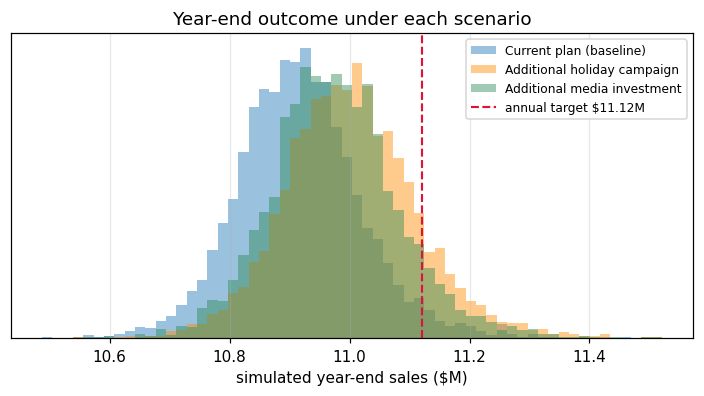

In [22]:
# The chapter's tables call the baseline scenario "Current plan (baseline)".
# The notebook keeps the forecasting term internally (the sync test maps the
# two), but anything printed into a figure follows the chapter.
CHAPTER_LABELS = {"Business as usual": "Current plan (baseline)"}

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = {"Business as usual": "#1f77b4",
          "Additional holiday campaign": "darkorange",
          "Additional media investment": "seagreen"}
scenario_values = {name: (sales_so_far + remaining + lift) / 1e6
                   for name, lift in scenarios.items()}
_all = np.concatenate(list(scenario_values.values()))
bins = np.linspace(_all.min(), _all.max(), 61)   # shared edges: comparable overlays
for name, values in scenario_values.items():
    ax.hist(values, bins=bins, density=True, alpha=0.45, color=colors[name],
            label=CHAPTER_LABELS.get(name, name))
ax.axvline(target / 1e6, color="crimson", lw=1.4, ls="--",
           label=f"annual target ${target/1e6:.2f}M")
ax.set_xlabel("simulated year-end sales ($M)")
ax.set_yticks([])
ax.set_title("Year-end outcome under each scenario")
ax.legend(fontsize=8)
save_fig(fig, "year_end_scenarios.png")
plt.show()

## 7. What would it take to hit the target?

The same numbers answer the reverse question: how much would the remaining
quarter have to beat the business-as-usual median, and how does that
compare with the evaluated historical windows?

In [23]:
required_uplift = (target - sales_so_far - np.median(remaining)) / np.median(remaining)
campaign_median_uplift = np.median(campaign_lift) / np.median(remaining)
media_median_uplift = np.median(media_lift) / np.median(remaining)
print(f"required uplift over the BAU median remaining: {required_uplift:+.1%}")
print(f"largest upside miss in a September window: {largest_sept_upside_miss:+.1%}")
print(f"largest upside miss among the {n_windows} non-overlapping validation "
      f"windows: {largest_evaluated_upside_miss:+.1%} "
      f"(window starting {weekly['week'].iloc[largest_miss_origin].date()})")
print(f"median campaign increment: {campaign_median_uplift:+.1%} of the quarter")
print(f"median media increment:    {media_median_uplift:+.1%} of the quarter")

required uplift over the BAU median remaining: +7.2%
largest upside miss in a September window: +6.0%
largest upside miss among the 15 non-overlapping validation windows: +11.9% (window starting 2016-07-04)
median campaign increment: +3.0% of the quarter
median media increment:    +2.1% of the quarter


## 8. What the generator knows (closing the loop)

In real work the story ends above: nobody hands you the truth. Because
this chapter's data is author-generated, we can check the workflow against
the data-generating process. Two checks: did the realized year land inside
the forecast band, and what would ACTUALLY have happened with the
campaign? The generator's true campaign lift is +7% on the four campaign
weeks; the geo-experiment estimate the scenario used (8% +/- 2.5pp) is
deliberately noisier, the way real measurements are.

In [24]:
truth = pd.read_csv(DATA_DIR / "ground_truth.csv", parse_dates=["week"])
realized_total = weekly["sales"].iloc[260:].sum()   # FY2019, read only here
realized_with_campaign = truth["sales_with_campaign"].iloc[260:].sum()
print(f"realized FY2019 (business as usual): ${realized_total/1e6:.2f}M "
      f"-> target {'hit' if realized_total >= target else 'missed'}")
print(f"inside the BAU 80% band? "
      f"{'yes' if p10 <= realized_total <= p90 else 'no'}")
print(f"counterfactual FY2019 with the campaign (true +7% lift): "
      f"${realized_with_campaign/1e6:.2f}M "
      f"-> target {'hit' if realized_with_campaign >= target else 'missed'}")
print(f"P(hit | campaign) said {scenario_table.loc['Additional holiday campaign', 'P(hit target)']:.0%}: "
      "an unlikely-but-possible outcome that, this time, did not come in.")

realized FY2019 (business as usual): $11.01M -> target missed
inside the BAU 80% band? yes
counterfactual FY2019 with the campaign (true +7% lift): $11.09M -> target missed
P(hit | campaign) said 13%: an unlikely-but-possible outcome that, this time, did not come in.


## Key numbers for the chapter

In [25]:
print(f"fiscal years: 2014-2019, 312 weeks, six 52-week years")
print(f"FY2018 total: ${completed.loc[2018]/1e6:.2f}M; growth trend ~5-7%/yr")
print(f"sales so far, FY2019 wk1-39: ${sales_so_far/1e6:.2f}M ({sales_so_far/prior_same-1:+.1%} YoY)")
print(f"target = FY2018 x {TARGET_MULTIPLIER}: ${target/1e6:.2f}M")
print()
print("backtest (3 September replicas):")
print(backtest.map(lambda v: f"{v:+.1%}").to_string())
print(f"random-split LightGBM WAPE: {random_split_wape:.1%}")
print(f"coverage: validation windows {sum(coverage_hits)}/{n_windows}, "
      f"September {sum(sept_hits)}/{len(sept_hits)}")
print()
print(f"BAU year-end P10/P50/P90: ${p10/1e6:.2f}M / ${p50/1e6:.2f}M / ${p90/1e6:.2f}M")
print(scenario_table.to_string(formatters=_FMT))
print(f"FY2018 promo-week gap vs surrounding weeks: {promo_gap:+.1%} (descriptive, not causal)")
print(f"required uplift {required_uplift:+.1%} vs largest September upside miss "
      f"{largest_sept_upside_miss:+.1%} "
      f"(validation windows: {largest_evaluated_upside_miss:+.1%})")

fiscal years: 2014-2019, 312 weeks, six 52-week years
FY2018 total: $10.30M; growth trend ~5-7%/yr
sales so far, FY2019 wk1-39: $8.02M (+7.3% YoY)
target = FY2018 x 1.08: $11.12M

backtest (3 September replicas):
                              weekly_wape mean_abs_total_error total_bias
model                                                                    
Naive                              +13.2%                +6.8%      -6.8%
Seasonal naive                      +8.6%                +5.5%      -5.5%
ETS (level + trend)                +13.3%                +4.7%      -4.7%
ETS (level + trend + season)        +7.4%                +2.6%      -1.3%
LightGBM (lags + calendar)         +12.3%                +5.7%      -5.7%
Prophet (calendar regressors)      +10.5%                +5.3%      +1.8%
TimesFM 2.5 (zero-shot)            +10.8%                +2.6%      -1.5%
random-split LightGBM WAPE: 4.5%
coverage: validation windows 12/15, September 2/3

BAU year-end P10/P50/P90: $10.79M / $